# MRI Super-Resolution — Image Quality Assessment

This notebook evaluates reconstruction quality of MRI super-resolution outputs on the **IXI dataset** using eight IQA metrics implemented in `main.py`.

---

## Metric Reference Thresholds

Thresholds derived from medical-imaging literature (MRI SR and image translation benchmarks).  
See `metrik_evaluation/report.md` for detailed justification and source papers.

| Metric | Direction | Perfect | Excellent | Good | Average | Bad |
|---|---|---|---|---|---|---|
| PSNR (dB) | ↑ higher | ∞ | > 40 | 33 – 40 | 25 – 33 | < 25 |
| SSIM | ↑ higher | 1.0 | > 0.97 | 0.90 – 0.97 | 0.75 – 0.90 | < 0.75 |
| LPIPS | ↓ lower | 0 | < 0.05 | 0.05 – 0.10 | 0.10 – 0.20 | > 0.20 |
| DISTS | ↓ lower | 0 | < 0.05 | 0.05 – 0.12 | 0.12 – 0.25 | > 0.25 |
| RadImageNet-LPIPS | ↓ lower | 0 | < 0.03 | 0.03 – 0.07 | 0.07 – 0.15 | > 0.15 |
| CLIP-IQA | ↑ higher | 1.0 | > 0.7 | 0.5 – 0.7 | 0.3 – 0.5 | < 0.3 |
| BRISQUE † | ↓ lower | 0 | < 10 | 10 – 30 | 30 – 60 | > 60 |
| NIQE † | ↓ lower | ~0 | < 2.5 | 2.5 – 4 | 4 – 10 | > 10 |

> **† BRISQUE / NIQE caveat:** Both metrics were designed for 8-bit natural images.  
> On MRI data, observed ranges are BRISQUE: 43 – 156 and NIQE: 22 – 93 (Müller et al., 2024).  
> Absolute values are **not reliable** for MRI — use them only for relative, within-study comparisons.

---

## Setup

The notebook lives in `src/`. The cell below ensures the working directory is always the **project root** so that the relative paths in `constants.py` (`data/`, `report/`, `models/`) resolve correctly regardless of how Jupyter or nbconvert was launched.

In [14]:
import os
import sys
from pathlib import Path

# Move to project root if nbconvert/Jupyter set cwd to src/
_cwd = Path.cwd()
if _cwd.name == "src":
    os.chdir(_cwd.parent)

# Make src/ importable
sys.path.insert(0, str(Path("src").resolve()))

print("Working directory:", Path.cwd())

Working directory: /mnt/home/stud-jagl1011/Documents/Projektarbeit_1/framework


## Experiment Configuration

Set `INPUT` and `TARGET` here before running the notebook.  
`TARGET = None` switches to a no-reference (NR-only) evaluation — full-reference metrics (PSNR, SSIM, LPIPS, DISTS, RadImageNet-LPIPS) will be skipped automatically.

In [15]:
# Experiment paths — edit these to evaluate a different image pair.
# Set TARGET = None for a no-reference (NR-only) evaluation.
#INPUT  = Path("data/smore/coronal/IXI661-HH-2788-T1/IXI661-HH-2788-T1_smore4.nii.gz")
#TARGET = Path("data/IXI_test_resampled/IXI661-HH-2788-T1.nii.gz")
INPUT  = Path("data/smore/coronal/")
TARGET = Path("data/IXI_test_resampled/")

THRESHOLDS = {
    "psnr":              [(25, "Bad/Avg", "red"), (33, "Avg/Good", "orange"), (40, "Good/Excel", "green")],
    "ssim":              [(0.75, "Bad/Avg", "red"), (0.90, "Avg/Good", "orange"), (0.97, "Good/Excel", "green")],
    "lpips":             [(0.20, "Bad/Avg", "red"), (0.10, "Avg/Good", "orange"), (0.05, "Good/Excel", "green")],
    "dists":             [(0.25, "Bad/Avg", "red"), (0.12, "Avg/Good", "orange"), (0.05, "Good/Excel", "green")],
    "radimagenet_lpips": [(0.15, "Bad/Avg", "red"), (0.07, "Avg/Good", "orange"), (0.03, "Good/Excel", "green")],
    "clipiqa":           [(0.30, "Bad/Avg", "red"), (0.50, "Avg/Good", "orange"), (0.70, "Good/Excel", "green")],
    "clip_iqa_lung":     [(0.30, "Bad/Avg", "red"), (0.50, "Avg/Good", "orange"), (0.70, "Good/Excel", "green")],
    "clip_iqa_brain":    [(0.30, "Bad/Avg", "red"), (0.50, "Avg/Good", "orange"), (0.70, "Good/Excel", "green")],
    "brisque":           [(60, "Bad/Avg", "red"), (30, "Avg/Good", "orange"), (10, "Good/Excel", "green")],
    "niqe":              [(10, "Bad/Avg", "red"), (4, "Avg/Good", "orange"), (2.5, "Good/Excel", "green")],
}


In [16]:
import math

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from main import evaluate, _METRIC_SPECS

## Evaluation

Calls `evaluate(INPUT, TARGET)` from `main.py`, which:
1. Loads the input volume and optional ground-truth reference set in the **Experiment Configuration** cell above.
2. Iterates over all slices, skipping empty ones.
3. Computes all registered IQA metrics per slice — **no files are written**.
4. Returns an `EvaluationResult`; call `result.generate_report()` in the optional block below to write outputs.

In [17]:
result = evaluate(INPUT, TARGET)
df = result.to_frame()

print(f"Total slices : {len(df)}")
print(f"Non-empty    : {(~df['is_empty']).sum()}")
df.head()

[IXI651-Guys-1118-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)
[IXI651-Guys-1118-T1.nii.gz] tensor size: (256, 1, 192, 256)
[IXI652-Guys-1116-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)
[IXI652-Guys-1116-T1.nii.gz] tensor size: (256, 1, 192, 256)
[IXI653-Guys-1122-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)
[IXI653-Guys-1122-T1.nii.gz] tensor size: (256, 1, 192, 256)
[IXI661-HH-2788-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)
[IXI661-HH-2788-T1.nii.gz] tensor size: (256, 1, 192, 256)
[IXI662-Guys-1120-T1_smore4.nii.gz] tensor size: (256, 1, 192, 256)
[IXI662-Guys-1120-T1.nii.gz] tensor size: (256, 1, 192, 256)
Total slices : 1280
Non-empty    : 1185


,image_id,source_model,mode,slice_index,is_empty,psnr,ssim,lpips,dists,radimagenet_lpips,clipiqa,clip_iqa_lung,clip_iqa_brain,brisque,niqe
0,IXI651-Guys-1118-T1_smore4_s000,None,full_reference,0,False,35.569721,0.931416,0.032471,0.098314,1.192750,0.527836,0.340165,0.424297,17.915710,9.493551
1,IXI651-Guys-1118-T1_smore4_s001,None,full_reference,1,False,35.638374,0.932878,0.033097,0.095466,1.184224,0.518043,0.305347,0.411779,24.685730,9.375838
2,IXI651-Guys-1118-T1_smore4_s002,None,full_reference,2,False,35.681450,0.933421,0.030638,0.099712,1.190924,0.517448,0.326338,0.422512,21.759949,9.781196
3,IXI651-Guys-1118-T1_smore4_s003,None,full_reference,3,False,35.686539,0.934342,0.031580,0.114070,1.174325,0.501951,0.336270,0.415694,18.298523,9.774781
4,IXI651-Guys-1118-T1_smore4_s004,None,full_reference,4,False,35.686764,0.934858,0.033404,0.086095,1.142121,0.504574,0.340992,0.430962,19.110535,8.813127


## Descriptive Statistics

In [18]:
# Derive a per-file key by stripping the known "_s###" slice suffix from image_id.
# Works for both single-file and directory runs, with or without source_model prefix.
df["volume"] = [iid[: -len(f"_s{si:03d}")] for iid, si in zip(df["image_id"], df["slice_index"])]

active = df[~df["is_empty"]]

if active.empty:
    raise RuntimeError(
        f"No non-empty slices found. Total rows: {len(df)}. "
        "Check that INPUT points to a valid image file or directory."
    )

# Derive metric list from _METRIC_SPECS — automatically includes any future metrics
# and skips full-reference metrics when no target was available (all-NaN columns).
metric_cols = [
    s.name for s in _METRIC_SPECS
    if s.name in active.columns and active[s.name].notna().any()
]

if not metric_cols:
    raise RuntimeError(
        "All metric columns are NaN — metric computation failed for every slice. "
        "Check the console output above for per-metric error messages."
    )

active[metric_cols].describe().round(4)

,psnr,ssim,lpips,dists,radimagenet_lpips,clipiqa,clip_iqa_lung,clip_iqa_brain,brisque,niqe
count,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000,1185.0000
mean,38.5980,0.9724,0.0188,0.0566,0.2753,0.4337,0.3522,0.4355,26.7123,7.9804
std,2.4038,0.0134,0.0085,0.0132,0.2540,0.0704,0.0299,0.0510,21.0192,5.2565
min,35.1558,0.9281,0.0005,0.0100,0.0194,0.1544,0.2423,0.2314,2.3069,4.0163
25%,36.9438,0.9658,0.0118,0.0480,0.1042,0.3997,0.3336,0.4223,14.5925,5.1856
50%,38.0024,0.9737,0.0189,0.0577,0.1840,0.4446,0.3498,0.4454,20.4089,5.9443
75%,39.9857,0.9810,0.0258,0.0650,0.3139,0.4810,0.3708,0.4660,29.0004,8.1943
max,48.4072,0.9970,0.0501,0.1141,1.1927,0.5663,0.4436,0.5366,109.9997,30.4920


## Per-Metric Score Distributions

Each histogram shows the distribution of values across all non-empty slices.  
The coloured vertical lines mark the **Good / Average** thresholds from the reference table above.

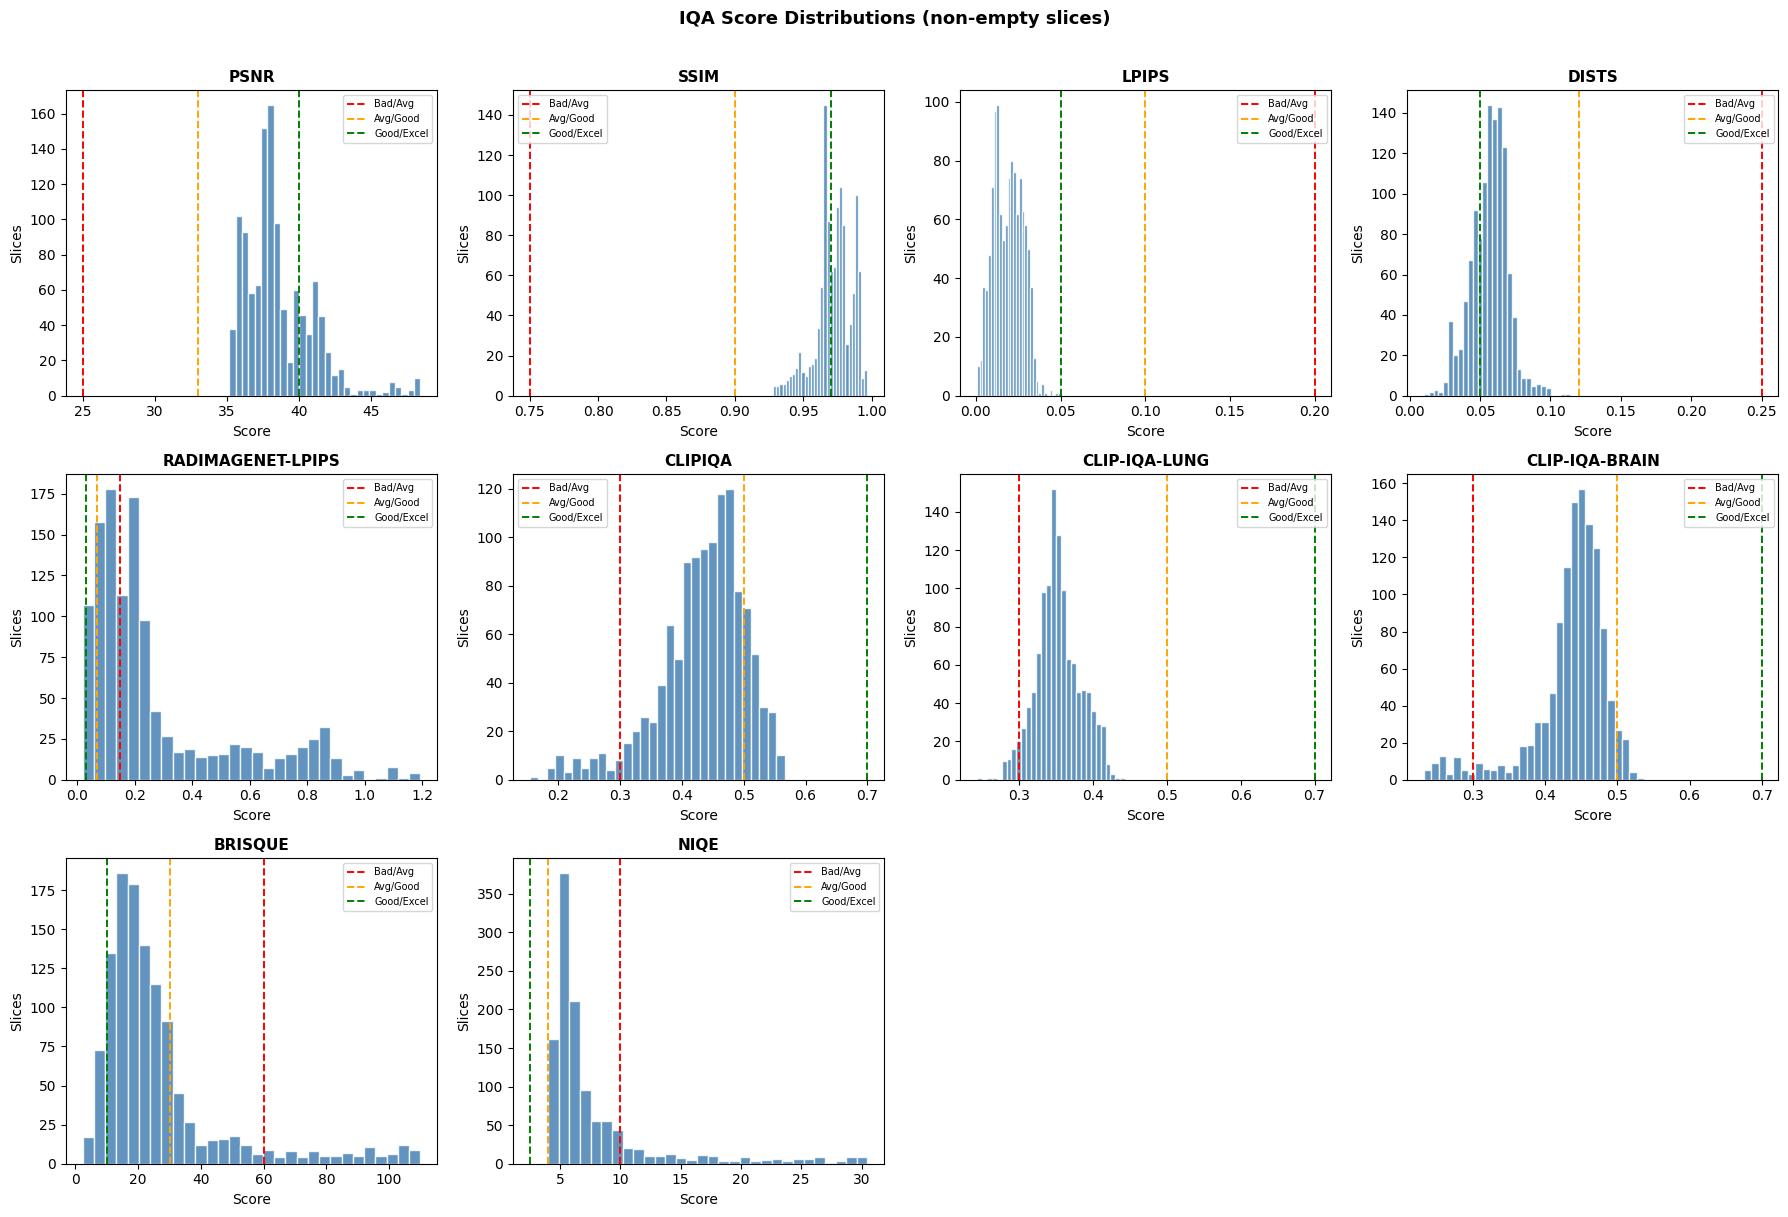

In [19]:
# Threshold lines: (value, label, colour)
# clip_iqa_lung / clip_iqa_brain share the same [0,1] scale and direction as
# clipiqa — thresholds from metrik_evaluation/report.md §6.


# Dynamic grid — adapts to however many metrics are active
n     = len(metric_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, metric_cols):
    data = active[col].dropna()
    ax.hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    for val, label, color in THRESHOLDS.get(col, []):
        ax.axvline(val, color=color, linestyle="--", linewidth=1.4, label=label)
    ax.set_title(col.upper().replace("_", "-"), fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Slices")
    ax.legend(fontsize=7)

# Hide unused subplot slots (if n is not a multiple of ncols)
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("IQA Score Distributions (non-empty slices)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Per-Metric Boxplots

Each metric gets one subplot with **one boxplot per evaluated file**, placed side by side.  
This allows direct quality comparison across files/datasets.  
Files are identified by colour — see the shared legend on the right.  
Dashed threshold lines mark the **Good / Average** boundaries from the reference table above.

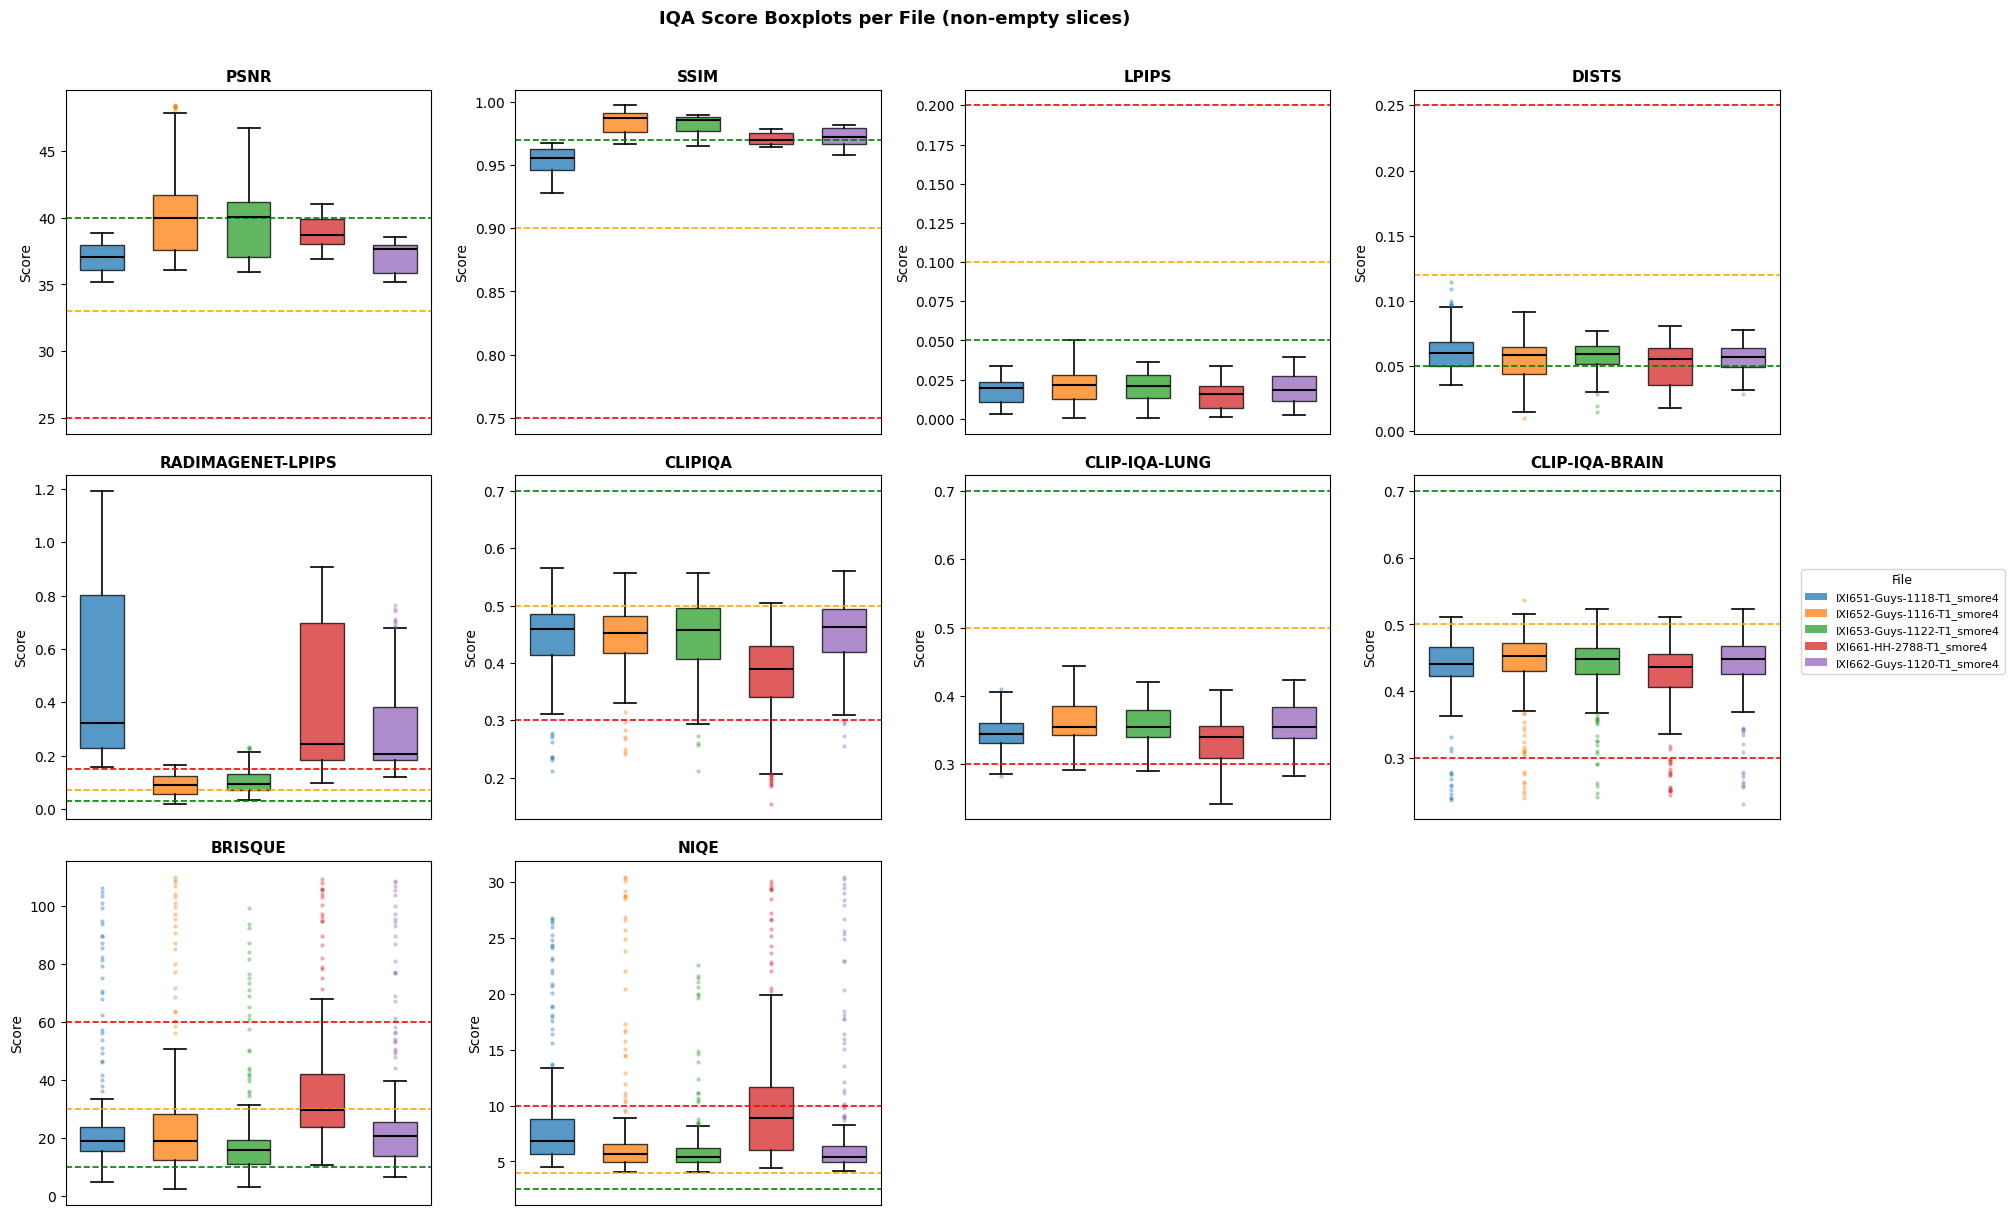

In [20]:
volumes = sorted(active["volume"].unique())
cmap = plt.get_cmap("tab10" if len(volumes) <= 10 else "tab20")
vol_colors = {v: cmap(i % cmap.N) for i, v in enumerate(volumes)}

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, metric_cols):
    groups = [active.loc[active["volume"] == v, col].dropna().values for v in volumes]
    bp = ax.boxplot(
        groups,
        positions=range(1, len(volumes) + 1),
        patch_artist=True,
        widths=0.6,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4, markeredgewidth=0),
    )
    for patch, v in zip(bp["boxes"], volumes):
        patch.set_facecolor(vol_colors[v])
        patch.set_alpha(0.75)
    for flier, v in zip(bp["fliers"], volumes):
        flier.set_markerfacecolor(vol_colors[v])
    for val, _label, color in THRESHOLDS.get(col, []):
        ax.axhline(val, color=color, linestyle="--", linewidth=1.2)
    ax.set_title(col.upper().replace("_", "-"), fontsize=11, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xticks([])

for ax in axes[n:]:
    ax.set_visible(False)

# Shared figure-level legend — one entry per file, colour matches all subplots
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=vol_colors[v], alpha=0.75)
    for v in volumes
]
fig.legend(handles, volumes, title="File", loc="center left",
           bbox_to_anchor=(1.0, 0.5), fontsize=8, title_fontsize=9)

fig.suptitle("IQA Score Boxplots per File (non-empty slices)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---

## Optional: Generate Full Report

The cell below writes the **CSV report** and **segmentation mask images** (slice / mask / overlay PNG for the best slice of each metric) to disk.

**Edit `report_path`** to change the output location, then run the cell.

In [21]:
# from pathlib import Path

# report_path = Path("report") / "IXI661_report.csv"   # <- edit output path here

# result.generate_report(report_path)